In [1]:
#IMPORTING DATA
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from matplotlib.ticker import FuncFormatter
import numpy as np
plt.figure(figsize=(10, 6))
plt.style.use("ggplot")
os.chdir(r"C:\Users\User\Downloads")
print(os.getcwd())
df = pd.read_excel("Super Store.xlsx")
df.head()

C:\Users\User\Downloads


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-12-06 00:00:00,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


<Figure size 1000x600 with 0 Axes>

In [6]:
#CLEANING 
print (df.info())
print (df.isnull().sum())
print (df.describe())
print (df.duplicated())
print (df["Name"])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [7]:
#ADDING MONTH & YEAR
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])
df["Year"] = df["Order Date"].dt.year
df["Month"] = df["Order Date"].dt.month_name()
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month
0,1,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,August
1,2,CA-2016-152156,2016-08-11,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,August
2,3,CA-2016-138688,2016-12-06,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,December
3,4,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,November
4,5,US-2015-108966,2015-11-10,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,November


In [8]:
#KPI'S

#TOTAL SALES
print (df["Sales"].sum())

2297200.8603


In [9]:
#TOTAL PROFIT
print (df["Profit"].sum())

286397.0217


In [10]:
#TOTAL ORDER
print (df["Order ID"].nunique())

5009


In [11]:
#TOTAL CUSTOMERs
print (df["Customer ID"].nunique())

793


In [12]:
#AVERAGE ORDER VALUE
print (df["Sales"].sum() / df["Order ID"].nunique())

458.6146656618087


In [13]:
#OUTLIERS
Sales= df["Sales"]
Q1 = Sales.quantile(0.25) 
Q3 = Sales.quantile(0.75) 
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR 
upper = Q3 + 1.5 *  IQR 

outliers = Sales[(Sales < lower) | (Sales > upper)] 
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Limit:", lower)
print("Upper Limit:", upper)
print("Outliers:")
print(outliers)

Q1: 17.28
Q3: 209.94
IQR: 192.66
Lower Limit: -271.71000000000004
Upper Limit: 498.93
Outliers:
1        731.9400
3        957.5775
7        907.1520
10      1706.1840
11       911.4240
          ...    
9931     683.3320
9942     998.8200
9947    1925.8800
9948    2405.2000
9968     735.9800
Name: Sales, Length: 1167, dtype: float64


object


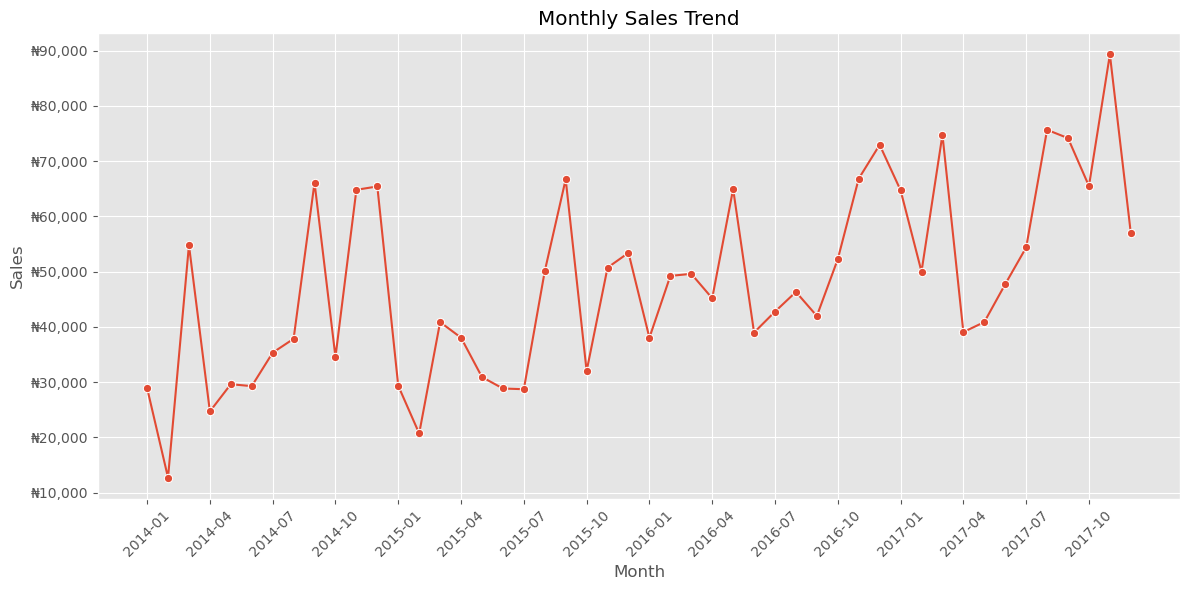

In [2]:
#LINE CHART
print(df["Order Date"].dtype)
df["Order Date"] = pd.to_datetime(df["Order Date"])

Monthly_Sales = df.groupby(
    df["Order Date"].dt.to_period("M")
)["Sales"].sum().reset_index()

Monthly_Sales["Order Date"] = Monthly_Sales["Order Date"].astype(str)
plt.figure(figsize=(12,6))
sns.lineplot(data=Monthly_Sales,x="Order Date",y="Sales",marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
def naira (x,pos):
    return f"₦{x:,.0f}"
plt.gca().yaxis.set_major_formatter(FuncFormatter(naira))
plt.xticks(rotation=46)
plt.xticks(
    ticks=range(0, len(Monthly_Sales), 3),
    labels=Monthly_Sales["Order Date"].iloc[::3],
    rotation=45
)

plt.tight_layout()
plt.show()

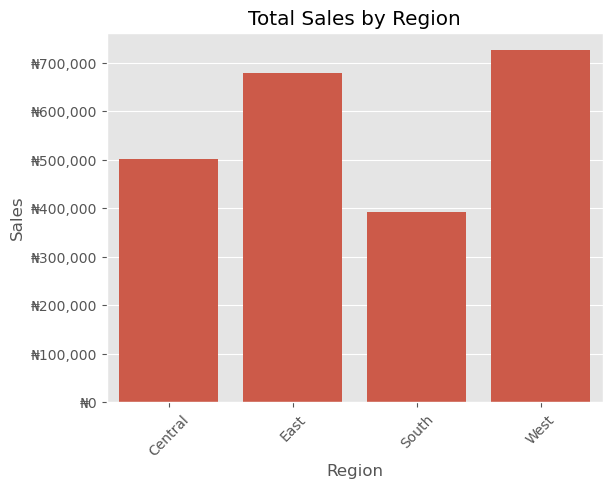

In [23]:
#BAR CHART
sales_region = df.groupby("Region")["Sales"].sum().reset_index()

sns.barplot(data=sales_region, x="Region", y="Sales")

plt.title("Total Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
def naira (x,pos):
    return f"₦{x:,.0f}"
plt.gca().yaxis.set_major_formatter(FuncFormatter(naira))
plt.xticks(rotation=46)

plt.show()

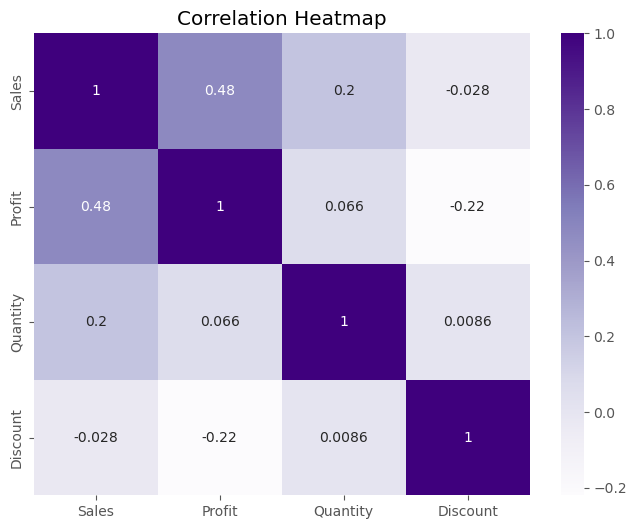

In [24]:
#HEAT MAP
plt.figure(figsize=(8,6))

sns.heatmap(
    df[["Sales","Profit","Quantity","Discount"]].corr(),
    annot=True,
    cmap="Purples"
)

plt.title("Correlation Heatmap")

plt.show()

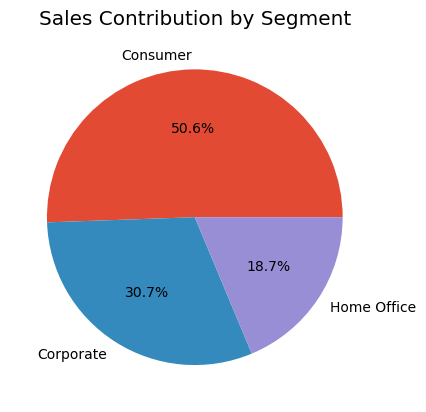

In [26]:
#PIE CHART
segment_sales = df.groupby("Segment")["Sales"].sum()

plt.pie(
    segment_sales,
    labels=segment_sales.index,
    autopct="%1.1f%%"
)

plt.title("Sales Contribution by Segment")

plt.show()

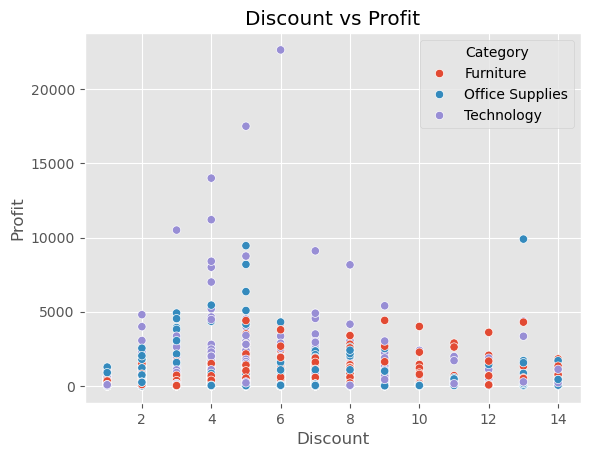

In [6]:
#SCATTERED PLOT
sns.scatterplot(
    data=df,
    x="Quantity",
    y="Sales",
    hue="Category"
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.show()

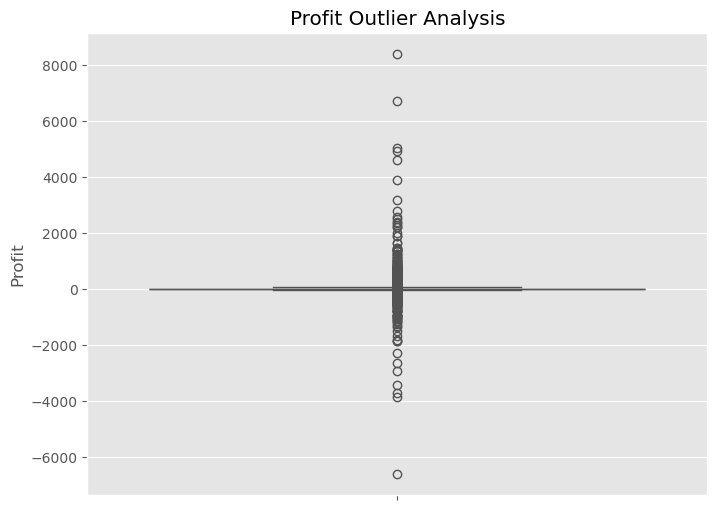

In [29]:
#PROFIT OUTLIER ANALYSIS
plt.figure(figsize=(8,6))

sns.boxplot(
    y=df["Profit"]
)

plt.title("Profit Outlier Analysis")
plt.ylabel("Profit")

plt.show()

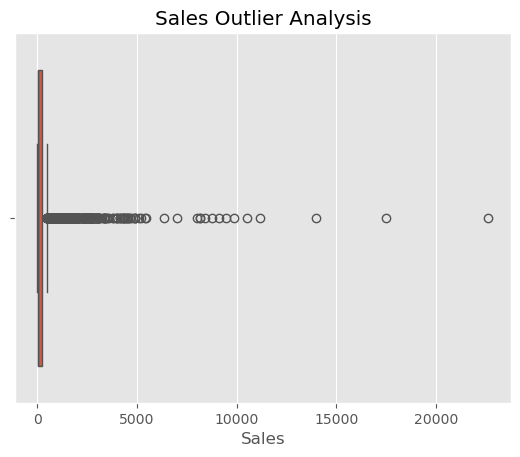

In [32]:
#SALES OUTLIER ANALYSIS
Sales= df["Sales"]
sns.boxplot(x=df["Sales"])
plt.title("Sales Outlier Analysis")
plt.show()